In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

from scipy import stats
from statsmodels.miscmodels.ordinal_model import OrderedModel
import statsmodels.formula.api as smf
import statsmodels.api as sm

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

In [ ]:

os.chdir("C:\\Users\\user\\Desktop\\saint jean\\semetre2\\STAT\\statistiqueTp\\stat")
# os.chdir("C:\\Users\\mngono\\Desktop\\tp-sn-python\\stat")

dataIR = pd.read_stata("CMIR71FL.DTA", convert_categoricals=False)


In [ ]:
# ── Fichier KR (enfants) ─────────────────────────────
dataKR = pd.read_spss("CMKR71FL.SAV")


In [ ]:
# print("Shape dataHR:", dataHR.shape)
print("Shape dataIR:", dataIR.shape)
# print("Shape dataPR:", dataPR.shape)
print("Shape dataKR:", dataKR.shape)

Shape dataIR: (14677, 5102)
Shape dataKR: (9733, 1212)


In [ ]:
# print("Types dataHR :")
# print(dataHR.dtypes)
print("\nTypes dataIR :")
print(dataIR.dtypes)
# print("\nTypes dataPR :")
# print(dataPR.dtypes)
print("\nTypes dataKR :")
print(dataKR.dtypes)


Types dataIR :
caseid      object
v000        object
v001         int16
v002         int16
v003          int8
            ...   
s233c_2    float64
s233c_3    float64
s233c_4    float64
s233c_5    float64
s233c_6    float64
Length: 5102, dtype: object

Types dataKR :
CASEID       object
MIDX        float64
V000         object
V001        float64
V002        float64
             ...   
S508Y1     category
SD508Y1    category
SM508Y1    category
SY508Y1    category
S619A      category
Length: 1212, dtype: object


In [ ]:
# Convertir toutes les colonnes KR en minuscules
dataKR.columns = dataKR.columns.str.lower()


# Vérification
print("KR colonnes (après correction) :")
print(dataKR.columns[:10].tolist())

print("KR :", dataKR.shape)

KR colonnes (après correction) :
['caseid', 'midx', 'v000', 'v001', 'v002', 'v003', 'v004', 'v005', 'v006', 'v007']
KR : (9733, 1212)


In [ ]:
# Garder uniquement les variables utiles
variables_KR = [
    'caseid', 'v001', 'v002', 'v005',      # identifiants
    'hw56', 'hw57',                          # anémie
    'b4', 'b19', 'hw70', 'hw72',            # enfant
    'h11', 'h22', 'h31', 'h42', 'h43', 'm4', # santé enfant
    'v012', 'v106', 'v133', 'v151',          # mère
    'v201', 'v457', 'v025', 'v024',          # mère & contexte
    'v190', 'v113', 'v116', 'v445'           # ménage
]

# Garder seulement les variables qui existent
variables_dispo = [v for v in variables_KR if v in dataKR.columns]
variables_absentes = [v for v in variables_KR if v not in dataKR.columns]

print(" Variables disponibles :", variables_dispo)
print(" Variables absentes    :", variables_absentes)

 Variables disponibles : ['caseid', 'v001', 'v002', 'v005', 'hw56', 'hw57', 'b4', 'b19', 'hw70', 'hw72', 'h11', 'h22', 'h31', 'h42', 'h43', 'm4', 'v012', 'v106', 'v133', 'v151', 'v201', 'v457', 'v025', 'v024', 'v190', 'v113', 'v116', 'v445']
 Variables absentes    : []


In [ ]:
rename_map = {
    # identifiants
    'caseid': 'id_menage',
    'v001': 'cluster',
    'v002': 'menage',
    'v005': 'poids_echantillon',

    # santé enfant (anémie / nutrition)
    'hw56': 'hémoglobine',
    'hw57': 'anemie',
    'hw70': 'zscore_taille_age',
    'hw72': 'zscore_poids_taille',

    # enfant
    'b4': 'sexe_enfant',
    'b19': 'age_enfant_mois',
    'm4': 'type_allaitement',

    # santé enfant (questions)
    'h11': 'diarrhee',
    'h22': 'fievre',
    'h31': 'toux',
    'h42': 'prise_fer',
    'h43': 'deparasitage',

    # mère
    'v012': 'age_mere',
    'v106': 'niveau_instruction',
    'v133': 'annees_education',
    # sexe_chef_menage
    'v151': 'sexe_chef_menage',

    # contexte enfant / ménage
    'v201': 'nombre_enfants_nes',
    'v457': 'anemie_mere',
    'v025': 'milieu_residence',
    'v024': 'region',

    # richesse / conditions ménage
    'v190': 'indice_richesse',
    'v113': 'source_eau',
    'v116': 'type_toilettes',
    'v445': 'BMI'
}


In [ ]:
# ── 2. Créer le dataframe ─────────────────────────────
dfKR = dataKR[variables_dispo].rename(columns=rename_map)

# ── Nettoyage des flags DHS sur dfKR (après renommage) ──
# ✅ Bug 1 corrigé : liste explicite des colonnes numériques à nettoyer
cols_flags = ['hemoglobine', 'zscore_taille_age', 'zscore_poids_taille', 'BMI']

for col in cols_flags:
    # ✅ Bug 2 corrigé : vérifier dans dfKR (noms renommés)
    if col in dfKR.columns:
        # ✅ Bug 3 corrigé : nettoyer dfKR, pas dataKR
        dfKR[col] = pd.to_numeric(dfKR[col], errors='coerce')
        dfKR[col] = dfKR[col].replace([9996, 9997, 9998, 9999], np.nan)
        n = dfKR[col].isna().sum()
        print(f"{col:<26} → {n:,} manquants ({n/len(dfKR)*100:.1f}%)")

zscore_taille_age          → 5,236 manquants (53.8%)
zscore_poids_taille        → 5,256 manquants (54.0%)
BMI                        → 4,544 manquants (46.7%)


In [ ]:
dfKR.isnull().sum()

id_menage                 0
cluster                   0
menage                    0
poids_echantillon         0
hémoglobine            5746
anemie                 5746
sexe_enfant               0
age_enfant_mois           0
zscore_taille_age      5236
zscore_poids_taille    5256
diarrhee                648
fievre                  648
toux                    648
prise_fer               648
deparasitage            648
type_allaitement          0
age_mere                  0
niveau_instruction        0
annees_education          0
sexe_chef_menage          0
nombre_enfants_nes        0
anemie_mere            4587
milieu_residence          0
region                    0
indice_richesse           0
source_eau                0
type_toilettes            0
BMI                    4544
dtype: int64

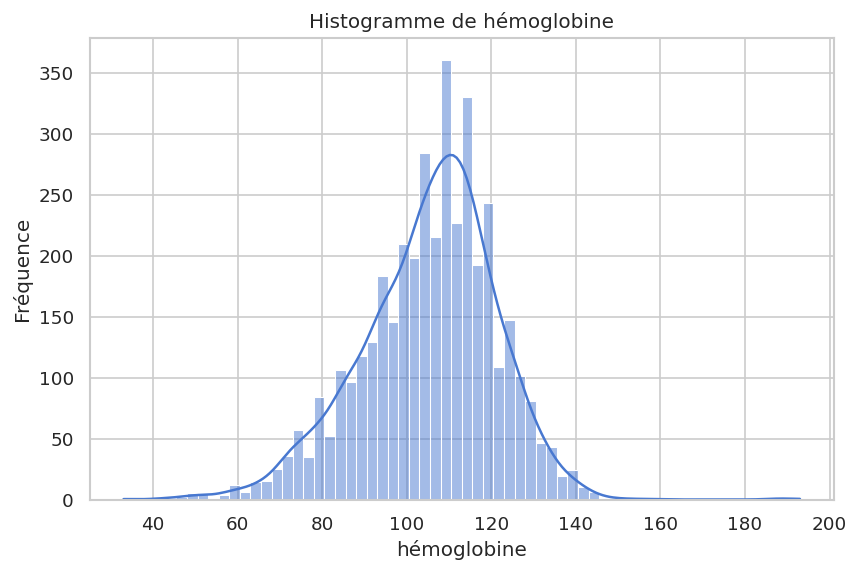

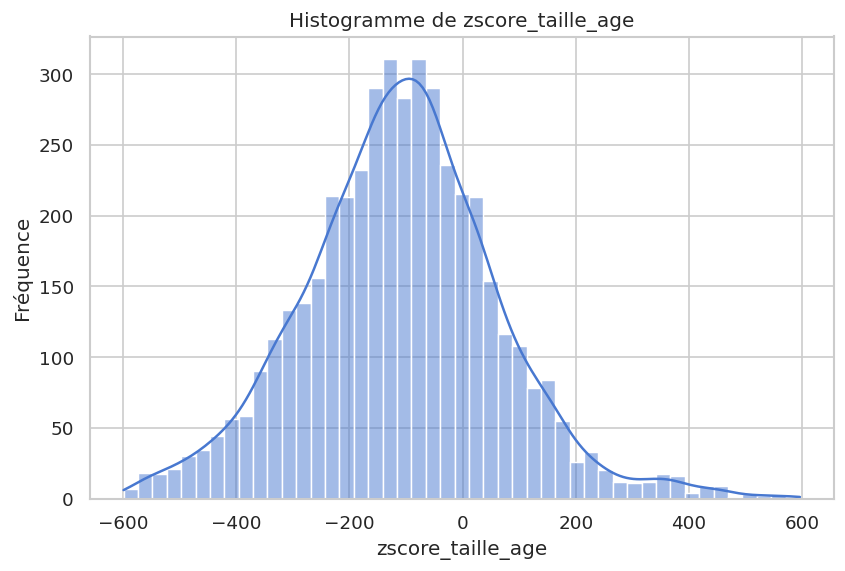

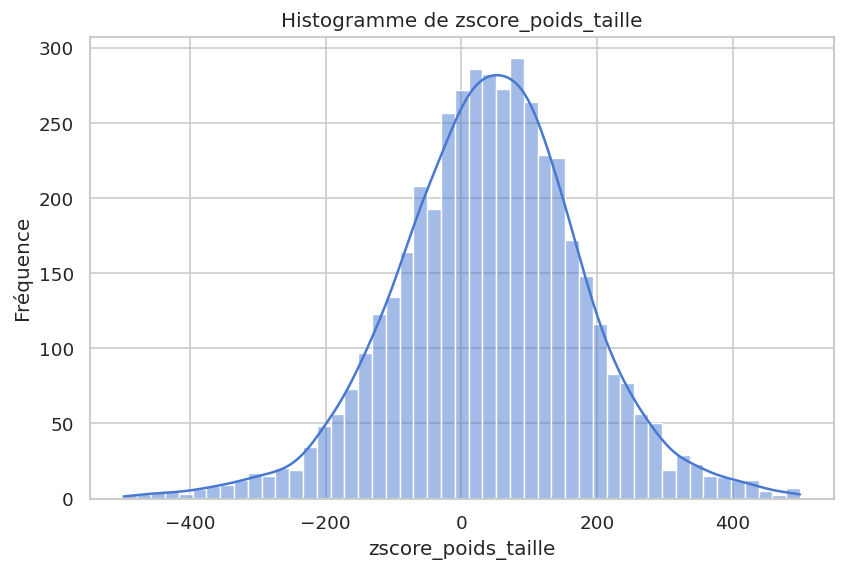

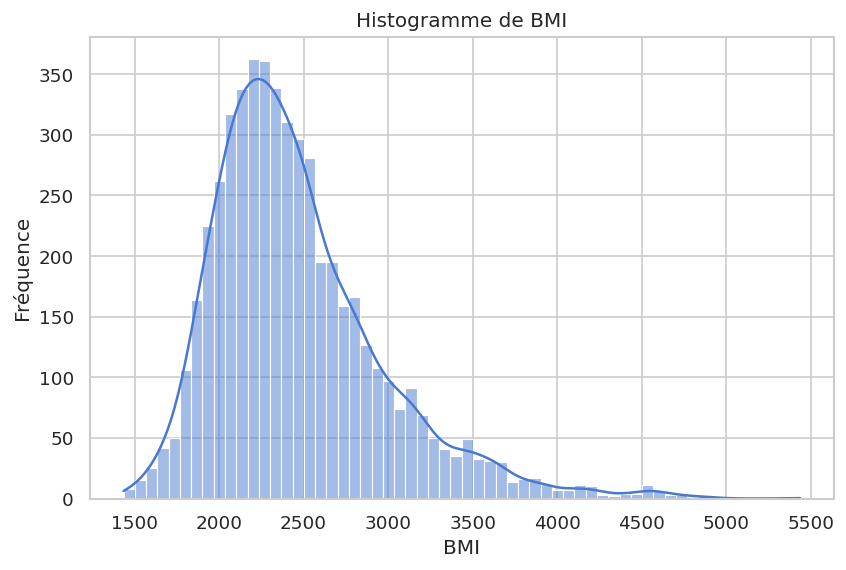

In [ ]:


# Liste des variables pour verifier quel loi suivre chaque variable
variablesQantitatives = [
    'hémoglobine','zscore_taille_age','zscore_poids_taille',
    'BMI'
]
for col in variablesQantitatives:

    data = pd.to_numeric(dfKR[col], errors='coerce')

    plt.figure(figsize=(8,5))

    # Si variable catégorielle (peu de valeurs uniques)
    if data.nunique() <= 10:

        sns.countplot(x=data)
        plt.title(f"Distribution de {col} (catégorielle)")

    else:

        sns.histplot(data, kde=True)
        plt.title(f"Histogramme de {col}")

    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.show()

In [ ]:
print(dfKR['sexe_enfant'].value_counts(dropna=False))

sexe_enfant
Male      4938
Female    4795
Name: count, dtype: int64


In [ ]:
# ── Imputation par la médiane globale (hemoglobine) ──────────
col = 'hemoglobine'
if col in dfKR.columns:
    dfKR[col] = pd.to_numeric(dfKR[col], errors='coerce')
    med = dfKR[col].median()
    dfKR[col] = dfKR[col].fillna(med)
    print(f"{col:<26} → médiane globale : {med:.3f}")

# ── Imputation par la médiane du cluster (z-scores + BMI) ────
cols_cluster = ['zscore_taille_age', 'zscore_poids_taille', 'BMI']

for col in cols_cluster:
    if col in dfKR.columns:
        dfKR[col] = pd.to_numeric(dfKR[col], errors='coerce')

        # Médiane par cluster, puis médiane globale si cluster entier manquant
        med_cluster = dfKR.groupby('cluster')[col].transform('median')
        med_globale = dfKR[col].median()

        dfKR[col] = dfKR[col].fillna(med_cluster).fillna(med_globale)

        n_restant = dfKR[col].isna().sum()
        print(f"{col:<26} → médiane cluster + globale | NA restants : {n_restant}")

zscore_taille_age          → médiane cluster + globale | NA restants : 0
zscore_poids_taille        → médiane cluster + globale | NA restants : 0
BMI                        → médiane cluster + globale | NA restants : 0


In [ ]:
print(dfKR['sexe_enfant'].value_counts(dropna=False))

sexe_enfant
Male      4938
Female    4795
Name: count, dtype: int64


In [ ]:
print(dfKR['anemie'].value_counts())
print(dfKR['anemie_mere'].value_counts())

anemie
Not anemic    1695
Moderate      1194
Mild          1018
Severe          80
Name: count, dtype: int64
anemie_mere
Not anemic    3108
Mild          1110
Moderate       890
Severe          38
Name: count, dtype: int64


In [ ]:
# Vérifier le type actuel
print(dfKR['hémoglobine'].dtype)
print(dfKR['hémoglobine'].value_counts())

category
hémoglobine
112.0    142
109.0    130
113.0    127
108.0    121
102.0    119
        ... 
147.0      1
149.0      1
152.0      1
157.0      1
193.0      1
Name: count, Length: 106, dtype: int64


In [ ]:
# Conversion : Categorical → numérique → g/dL réel
dfKR['hémoglobine'] = pd.to_numeric(dfKR['hémoglobine'], errors='coerce') / 10

moyenne = dfKR['hémoglobine'].mean()
print(f"Moyenne Hb : {moyenne:.2f} g/dL")

Moyenne Hb : 10.52 g/dL


In [ ]:
# ── 3. Mappings des variables catégorielles ───────────
mappings = {
    'sexe_enfant': {'Male': 1, 'Female': 0},
    'milieu_residence' :{'Urban': 0, 'Rural': 1},
    # 'Plus pauvre': 1, 'Pauvre': 2, 'Moyen': 3, 'Riche': 4, 'Plus riche': 5
    'indice_richesse': {'Poorest': 1, 'Poorer': 2, 'Middle': 3, 'Richer': 4, 'Richest': 5},
    #   'Aucune instruction': 0, 'Primaire': 1,  'Secondaire': 2, 'Supérieur': 3
    'niveau_instruction': {'No education': 0, 'Primary': 1,'Secondary': 2,   'Higher': 3},
    # sexe_chef_menage
    'sexe_chef_menage': {'Male': 1, 'Female': 0},
    # 'Pas d’anémie': 0, 'Anémie légère': 1, 'Anémie modérée': 2,'Anémie sévère': 3
    'anemie':{'Not anemic': 0, 'Mild': 1,'Moderate': 2,'Severe': 3},
    'anemie_mere': {'Not anemic': 0, 'Mild': 1,'Moderate': 2,'Severe': 3 },
    # Région (10 régions Cameroun)
    'region': {
    'Far-North'                    : 1,
    'North'                        : 2,
    'Adamawa'                      : 3,
    'Centre (without Yaounde)'     : 4,
    'Yaounde'                      : 4,  
    'East'                         : 5,
    'West'                         : 6,
    'Littoral (without Douala)'    : 7,
    'Douala'                       : 7, 
    'North-West'                   : 8,
    'South-West'                   : 9,  
    'South'                        : 10,  
},
    # Consultation santé (h42 = prise de fer)
    'prise_fer': { 'No' : 0, 'Yes': 1, "Don't know" : np.nan
    },
    # Hospitalisation (h43 = déparasitage)
    'deparasitage': {'No': 0,'Yes': 1, "Don't know" : np.nan
    },
    # Type allaitement (pas accouchement !)
    'type_allaitement': { 'Never breastfed': 0,'Still breastfeeding': 1,
        'Ever breastfed, not currently breastfeeding': 2,
    },
'diarrhee' : {'No': 0, 'Yes, last two weeks': 1, "Don't know": np.nan},
'fievre'   : {'No': 0, 'Yes': 1,                 "Don't know": np.nan},
'toux'     : {'No': 0, 'Yes, last two weeks': 1,  "Don't know": np.nan},
 }


for col, mapping in mappings.items():
    if col in dfKR.columns:
        dfKR[col] = dfKR[col].map(mapping)
        n_na = dfKR[col].isna().sum()
        print(f"  {col:<26} → mappé | NA : {n_na:,}")
    else:
        print(f"  {col:<26} → ⚠ absent de dfKR")

# for col, mapping in mappings.items():
#     dfKR[col] = dfKR[col].map(mapping)

  sexe_enfant                → mappé | NA : 0
  milieu_residence           → mappé | NA : 0
  indice_richesse            → mappé | NA : 0
  niveau_instruction         → mappé | NA : 0
  sexe_chef_menage           → mappé | NA : 0
  anemie                     → mappé | NA : 5,746
  anemie_mere                → mappé | NA : 4,587
  region                     → mappé | NA : 0
  prise_fer                  → mappé | NA : 772
  deparasitage               → mappé | NA : 748
  type_allaitement           → mappé | NA : 0
  diarrhee                   → mappé | NA : 752
  fievre                     → mappé | NA : 731
  toux                       → mappé | NA : 739


In [ ]:
print(f"Dataset final : {dfKR.shape[0]} observations × {dfKR.shape[1]} variables\n")
print(f"{'Variable':<25} {'Type'}")
print("-" * 40)
for col in dfKR.columns:
    print(f"{col:<25} {dfKR[col].dtype}")

Dataset final : 9733 observations × 28 variables

Variable                  Type
----------------------------------------
id_menage                 object
cluster                   float64
menage                    float64
poids_echantillon         float64
hémoglobine               float64
anemie                    category
sexe_enfant               category
age_enfant_mois           float64
zscore_taille_age         float64
zscore_poids_taille       float64
diarrhee                  float64
fievre                    float64
toux                      float64
prise_fer                 float64
deparasitage              float64
type_allaitement          category
age_mere                  float64
niveau_instruction        category
annees_education          category
sexe_chef_menage          category
nombre_enfants_nes        float64
anemie_mere               category
milieu_residence          category
region                    int64
indice_richesse           category
source_eau            

In [ ]:
n_avant = len(dfKR)
dfKR = dfKR.dropna(subset=['anemie'])
n_apres = len(dfKR)

print(f"Avant  : {n_avant:,} lignes")
print(f"Après  : {n_apres:,} lignes")
print(f"Retirés: {n_avant - n_apres:,} lignes")
print(f"\nDistribution de l'anémie après nettoyage :")
print(dfKR['anemie'].value_counts().sort_index())



Avant  : 9,733 lignes
Après  : 3,987 lignes
Retirés: 5,746 lignes

Distribution de l'anémie après nettoyage :
anemie
1    1018
2    1194
0    1695
3      80
Name: count, dtype: int64


In [ ]:
# 80 cas sévères sur 3 987 = 2% — c'est insuffisant pour estimer un seuil ordinal stable avec des effets aléatoires multiniveaux.
# Solution recommandée : fusionner Modérée + Sévère

# 0 = Aucune | 1 = Légère | 2 = Modérée/Sévère
dfKR['anemie'] = dfKR['anemie'].replace({3: 2})

print("Distribution après regroupement :")
print(dfKR['anemie'].value_counts().sort_index())



Distribution après regroupement :
anemie
1    1018
2    1274
0    1695
Name: count, dtype: int64


In [ ]:
print(f"\nTotal : {len(dfKR):,}")
print(f"Nombre de clusters   : {dfKR['cluster'].nunique()}")
print(f"Nombre de régions    : {dfKR['region'].nunique()}")
print(f"Moy. enfants/cluster : {len(dfKR)/dfKR['cluster'].nunique():.1f}")


Total : 3,987
Nombre de clusters   : 428
Nombre de régions    : 10
Moy. enfants/cluster : 9.3


In [ ]:
cols_verif = ['anemie_mere', 'prise_fer', 'deparasitage', 'diarrhee', 'fievre', 'toux']

for col in cols_verif:
    n_na = dfKR[col].isna().sum()
    print(f"  {col:<26} → NA restants : {n_na}")

print(f"\nBilan global dfKR ({len(dfKR):,} lignes) :")
na_total = dfKR.isnull().sum()
na_total = na_total[na_total > 0]

if len(na_total) == 0:
    print("  ✅ Aucun NaN restant — dfKR prêt pour la modélisation")
else:
    print(na_total)

  anemie_mere                → NA restants : 25
  prise_fer                  → NA restants : 18
  deparasitage               → NA restants : 21
  diarrhee                   → NA restants : 3
  fievre                     → NA restants : 4
  toux                       → NA restants : 5

Bilan global dfKR (3,987 lignes) :
diarrhee         3
fievre           4
toux             5
prise_fer       18
deparasitage    21
anemie_mere     25
dtype: int64


In [ ]:
# Imputation globale pour les NaN résiduels
cols_restants = ['anemie_mere', 'prise_fer', 'deparasitage', 'diarrhee', 'fievre', 'toux']

for col in cols_restants:
    if dfKR[col].isna().sum() > 0:
        mode_global = dfKR[col].mode()[0]
        dfKR[col] = dfKR[col].fillna(mode_global)
        print(f"  {col:<26} → mode global = {mode_global}  ✅")

# Vérification finale
na_final = dfKR.isnull().sum().sum()
print(f"\n  NaN totaux restants : {na_final}")
print(f"  {'✅ dfKR propre — prêt pour la modélisation' if na_final == 0 else '⚠ Vérifier encore'}")

  anemie_mere                → mode global = 0  ✅
  prise_fer                  → mode global = 0.0  ✅
  deparasitage               → mode global = 1.0  ✅
  diarrhee                   → mode global = 0.0  ✅
  fievre                     → mode global = 0.0  ✅
  toux                       → mode global = 0.0  ✅

  NaN totaux restants : 0
  ✅ dfKR propre — prêt pour la modélisation


In [ ]:
# Correction d'échelle (valeurs × 100 dans les fichiers EDS)
# ── Division par 100 après mappings ───────────────────
dfKR['zscore_taille_age']   = dfKR['zscore_taille_age'] / 100
dfKR['zscore_poids_taille'] = dfKR['zscore_poids_taille'] / 100
dfKR['BMI']                 = dfKR['BMI'] / 100


# Supprimer les observations sans anémie renseignée
dfKR = dfKR[dfKR['anemie'].notna()].copy()
dfKR['anemie'] = dfKR['anemie'].astype(int)


# ── Vérification ──────────────────────────────────────
print("Après correction :")
print(f"  zscore_taille_age   : moy={dfKR['zscore_taille_age'].mean():.2f} [{dfKR['zscore_taille_age'].min():.2f} - {dfKR['zscore_taille_age'].max():.2f}]")
print(f"  zscore_poids_taille : moy={dfKR['zscore_poids_taille'].mean():.2f} [{dfKR['zscore_poids_taille'].min():.2f} - {dfKR['zscore_poids_taille'].max():.2f}]")
print(f"  BMI mère            : moy={dfKR['BMI'].mean():.2f} [{dfKR['BMI'].min():.2f} - {dfKR['BMI'].max():.2f}]")

Après correction :
  zscore_taille_age   : moy=-1.18 [-5.99 - 5.96]
  zscore_poids_taille : moy=0.39 [-4.98 - 4.99]
  BMI mère            : moy=24.57 [14.35 - 48.77]


In [ ]:
# dfKR['sexe_enfant'].value_counts(dropna=False)
# print(dfKR['sexe_enfant'])
print(f"Échantillon final : {dfKR.shape[0]} observations")

Échantillon final : 3987 observations


In [ ]:
dfKR.dtypes

id_menage                object
cluster                 float64
menage                  float64
poids_echantillon       float64
hémoglobine             float64
anemie                    int32
sexe_enfant            category
age_enfant_mois         float64
zscore_taille_age       float64
zscore_poids_taille     float64
diarrhee                float64
fievre                  float64
toux                    float64
prise_fer               float64
deparasitage            float64
type_allaitement       category
age_mere                float64
niveau_instruction     category
annees_education       category
sexe_chef_menage       category
nombre_enfants_nes      float64
anemie_mere            category
milieu_residence       category
region                    int64
indice_richesse        category
source_eau             category
type_toilettes         category
BMI                     float64
dtype: object

In [ ]:
# ══════════════════════════════════════════════════════
# ANALYSE UNIVARIÉE
# ══════════════════════════════════════════════════════

# ── Variables quantitatives ───────────────────────────
vars_quant = [
    'hemoglobine', 'age_enfant_mois', 'age_mere', 'BMI',
    'zscore_taille_age', 'zscore_poids_taille', 'nombre_enfants_nes'
]

# ── Variables catégorielles ───────────────────────────
vars_cat = [
    'anemie', 'sexe_enfant', 'milieu_residence', 'indice_richesse',
    'niveau_instruction', 'anemie_mere', 'fievre', 'diarrhee',
    'toux', 'prise_fer', 'deparasitage', 'type_allaitement',
    'sexe_chef_menage'
]

n = len(dfKR)

# ── 1. Tableau des variables quantitatives ────────────
print("=" * 65)
print("  VARIABLES QUANTITATIVES")
print("=" * 65)
print(f"  {'Variable':<26} {'Moy':>7} {'Méd':>7} {'ET':>7} {'Min':>7} {'Max':>7} {'NA%':>6}")
print("  " + "─" * 63)

for col in vars_quant:
    if col not in dfKR.columns:
        continue
    d    = pd.to_numeric(dfKR[col], errors='coerce')
    na_p = d.isna().sum() / n * 100
    print(f"  {col:<26} {d.mean():>7.2f} {d.median():>7.2f} "
          f"{d.std():>7.2f} {d.min():>7.2f} {d.max():>7.2f} {na_p:>5.1f}%")

# ── 2. Tableau des variables catégorielles ────────────
print(f"\n{'=' * 65}")
print("  VARIABLES CATÉGORIELLES")
print("=" * 65)

labels_map = {
    'anemie'           : {0:'Aucune', 1:'Légère', 2:'Mod/Sév'},
    'sexe_enfant'      : {1:'Masculin', 0:'Féminin'},
    'milieu_residence' : {0:'Urbain', 1:'Rural'},
    'indice_richesse'  : {1:'Très pauvre', 2:'Pauvre', 3:'Moyen', 4:'Riche', 5:'Très riche'},
    'niveau_instruction': {0:'Aucun', 1:'Primaire', 2:'Secondaire', 3:'Supérieur'},
    'anemie_mere'      : {0:'Aucune', 1:'Légère', 2:'Mod/Sév'},
    'fievre'           : {0:'Non', 1:'Oui'},
    'diarrhee'         : {0:'Non', 1:'Oui'},
    'toux'             : {0:'Non', 1:'Oui'},
    'prise_fer'        : {0:'Non', 1:'Oui'},
    'deparasitage'     : {0:'Non', 1:'Oui'},
    'type_allaitement' : {0:'Jamais', 1:'En cours', 2:'Sevré'},
    'sexe_chef_menage' : {1:'Masculin', 0:'Féminin'},
}

for col in vars_cat:
    if col not in dfKR.columns:
        continue
    print(f"\n  {col}")
    vc = dfKR[col].value_counts(dropna=False).sort_index()
    for val, cnt in vc.items():
        if pd.isna(val):
            lab = 'Manquant'
        else:
            lab = labels_map.get(col, {}).get(val, str(val))
        pct = cnt / n * 100
        bar = '█' * int(pct / 3)
        print(f"    {lab:<15} : {cnt:>5,}  ({pct:>5.1f}%)  {bar}")

  VARIABLES QUANTITATIVES
  Variable                       Moy     Méd      ET     Min     Max    NA%
  ───────────────────────────────────────────────────────────────
  age_enfant_mois              31.45   31.00   15.54    6.00   59.00   0.0%
  age_mere                     28.64   28.00    6.53   15.00   49.00   0.0%
  BMI                          24.57   23.58    4.99   14.35   48.77   0.0%
  zscore_taille_age            -1.18   -1.18    1.68   -5.99    5.96   0.0%
  zscore_poids_taille           0.39    0.43    1.34   -4.98    4.99   0.0%
  nombre_enfants_nes            3.91    3.00    2.33    1.00   14.00   0.0%

  VARIABLES CATÉGORIELLES

  anemie
    Aucune          : 1,695  ( 42.5%)  ██████████████
    Légère          : 1,018  ( 25.5%)  ████████
    Mod/Sév         : 1,274  ( 32.0%)  ██████████

  sexe_enfant
    Féminin         : 1,983  ( 49.7%)  ████████████████
    Masculin        : 2,004  ( 50.3%)  ████████████████

  milieu_residence
    Rural           : 2,193  ( 55.0%)  █

In [ ]:
dfKR.columns

Index(['id_menage', 'cluster', 'menage', 'poids_echantillon', 'hémoglobine',
       'anemie', 'sexe_enfant', 'age_enfant_mois', 'zscore_taille_age',
       'zscore_poids_taille', 'diarrhee', 'fievre', 'toux', 'prise_fer',
       'deparasitage', 'type_allaitement', 'age_mere', 'niveau_instruction',
       'annees_education', 'sexe_chef_menage', 'nombre_enfants_nes',
       'anemie_mere', 'milieu_residence', 'region', 'indice_richesse',
       'source_eau', 'type_toilettes', 'BMI'],
      dtype='object')

In [ ]:

# ── Vérification finale ────────────────────────────
print(f" Echantillon final  : {dfKR.shape[0]}")
print(f"Nombre de grappes : {dfKR['cluster'].nunique()}")
print(f"  Nombre de régions   : {dfKR['region'].nunique()}")
print("\nDistribution de l'anémie :")

for label, code in [
    ('Non anémique', 0),
    ('Légère', 1),
    ('Modérée', 2),
    ('Sévère', 3)
]:
    
    n = (dfKR['anemie'] == code).sum()

    print(f"{label:<15}: {n:>5} ({n/len(dfKR)*100:.1f}%)")


 Echantillon final  : 3987
Nombre de grappes : 428
  Nombre de régions   : 10

Distribution de l'anémie :
Non anémique   :  1695 (42.5%)
Légère         :  1018 (25.5%)
Modérée        :  1274 (32.0%)
Sévère         :     0 (0.0%)


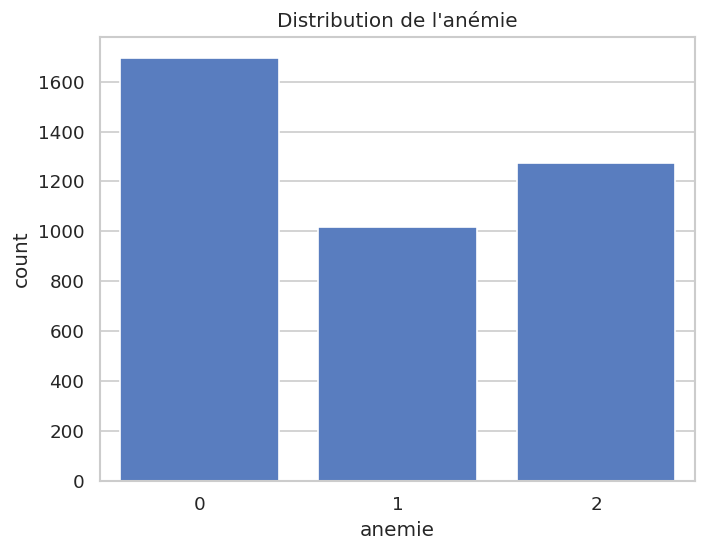

In [ ]:
sns.countplot(x=dfKR['anemie'])

plt.title("Distribution de l'anémie")
plt.show()

In [ ]:
print(dfKR.columns.tolist())

['id_menage', 'cluster', 'menage', 'poids_echantillon', 'hémoglobine', 'anemie', 'sexe_enfant', 'age_enfant_mois', 'zscore_taille_age', 'zscore_poids_taille', 'diarrhee', 'fievre', 'toux', 'prise_fer', 'deparasitage', 'type_allaitement', 'age_mere', 'niveau_instruction', 'annees_education', 'sexe_chef_menage', 'nombre_enfants_nes', 'anemie_mere', 'milieu_residence', 'region', 'indice_richesse', 'source_eau', 'type_toilettes', 'BMI']


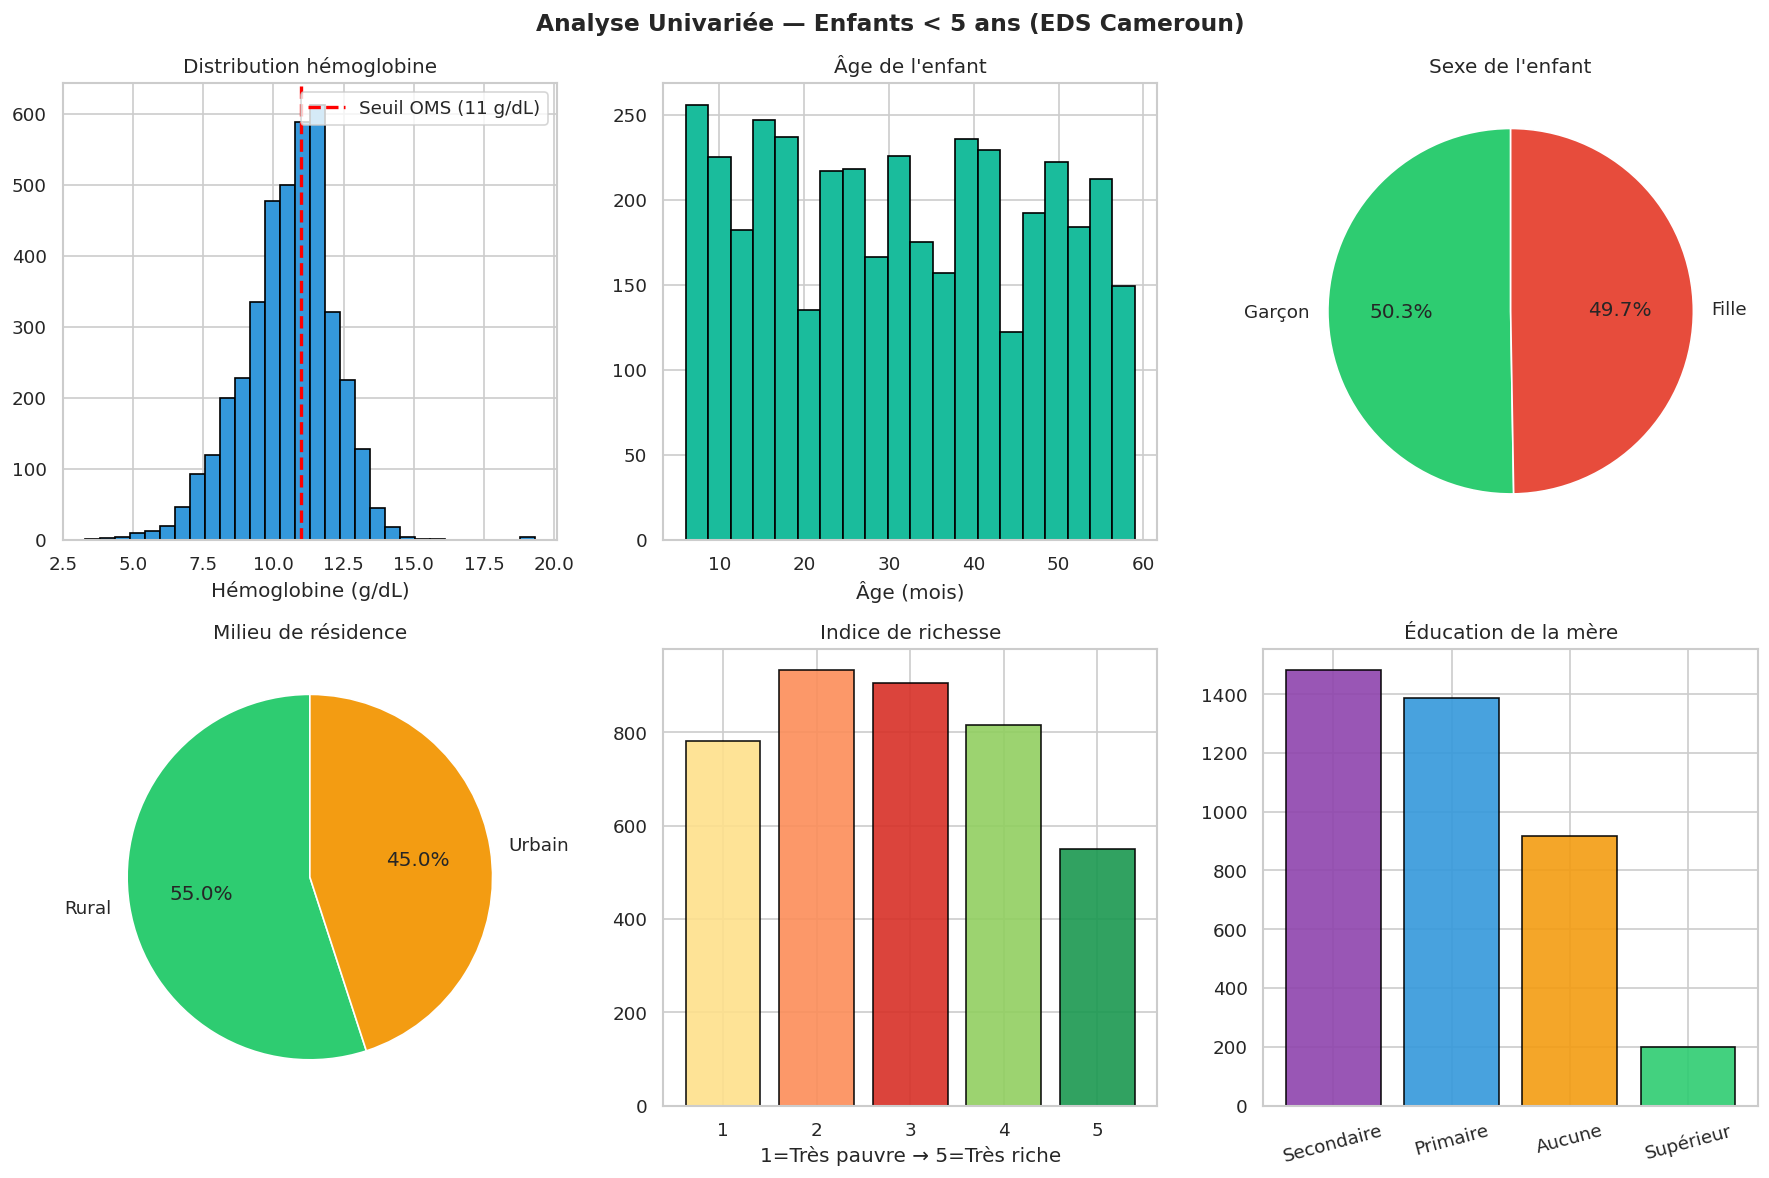

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Analyse Univariée — Enfants < 5 ans (EDS Cameroun)",
             fontsize=14, fontweight='bold')

color_hist = '#3498db'
color_cat1 = '#2ecc71'
color_cat2 = '#f39c12'
color_cat4 = '#e74c3c'

# 1 — Hémoglobine
axes[0,0].hist(dfKR['hémoglobine'].dropna(),          # ✅ sans accent
               bins=30, color=color_hist, edgecolor='black')
axes[0,0].axvline(x=11.0, color='red', linestyle='--',  # ✅ seuil g/dL
                  linewidth=2, label='Seuil OMS (11 g/dL)')
axes[0,0].set_title('Distribution hémoglobine')
axes[0,0].set_xlabel('Hémoglobine (g/dL)')
axes[0,0].legend()

# 2 — Âge enfant
axes[0,1].hist(dfKR['age_enfant_mois'].dropna(),
               bins=20, color='#1abc9c', edgecolor='black')
axes[0,1].set_title("Âge de l'enfant")
axes[0,1].set_xlabel('Âge (mois)')

# 3 — Sexe enfant
sex = dfKR['sexe_enfant'].map({1:'Garçon', 0:'Fille'}).value_counts()
axes[0,2].pie(sex.values, labels=sex.index, autopct='%1.1f%%',
              colors=[color_cat1, color_cat4], startangle=90)
axes[0,2].set_title("Sexe de l'enfant")                # ✅ guillemets doubles

# 4 — Milieu de résidence
milieu = dfKR['milieu_residence'].map({0:'Urbain', 1:'Rural'}).value_counts()
axes[1,0].pie(milieu.values, labels=milieu.index, autopct='%1.1f%%',
              colors=[color_cat1, color_cat2], startangle=90)
axes[1,0].set_title('Milieu de résidence')

# 5 — Indice de richesse
richesse = dfKR['indice_richesse'].value_counts().sort_index()
colors_richesse = ['#d73027','#fc8d59','#fee08b','#91cf60','#1a9850']
axes[1,1].bar(richesse.index, richesse.values,
              color=colors_richesse, edgecolor='black', alpha=0.9)
axes[1,1].set_title('Indice de richesse')
axes[1,1].set_xlabel('1=Très pauvre → 5=Très riche')

# 6 — Éducation de la mère
edu = dfKR['niveau_instruction'].map(
    {0:'Aucune', 1:'Primaire', 2:'Secondaire', 3:'Supérieur'}
).value_counts()
colors_edu = ['#8e44ad','#3498db','#f39c12','#2ecc71']
axes[1,2].bar(edu.index, edu.values,
              color=colors_edu, edgecolor='black', alpha=0.9)
axes[1,2].set_title('Éducation de la mère')
axes[1,2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('univarie.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# # ══════════════════════════════════════════════════════
# #           ÉTAPE  — ANALYSE BIVARIÉE
# # ══════════════════════════════════════════════════════
from scipy.stats import chi2_contingency, kruskal

# faire le test de chi deux 
# Le test du Chi² (chi-square) sert à vérifier s’il existe une association entre deux variables catégorielles

# Hypothèse nulle (H0)
# Il n’y a aucune association entre les deux variables
# La variable explicative et l’anémie sont indépendantes

# Hypothèse alternative (H1)
# Il existe une association entre les deux variables
# elles ne sont pas indépendantes

dfKR = dfKR[dfKR['anemie'].notna()].copy()
dfKR['anemie'] = dfKR['anemie'].astype(int)

vars_cat = {
    'sexe_enfant': 'Sexe enfant',
    'milieu_residence': 'Milieu de résidence',
    'indice_richesse': 'Indice de richesse',
    'niveau_instruction': 'Éducation de la mère',
    'anemie_mere': 'Anémie de la mère',
    'diarrhee': 'Diarrhée',
    'fievre': 'Fièvre',
    'toux': 'Toux'
}

print(f"\n{'Variable':<25} {'Chi²':>8} {'p-value':>10} {'Sig':>6}")
print("-" * 55)

for var, label in vars_cat.items():
    tab = pd.crosstab(dfKR[var], dfKR['anemie'])
    
    chi2, p, dof, _ = chi2_contingency(tab)
    sig = "✅" if p < 0.05 else "❌"
    
    print(f"{label:<25} {chi2:>8.2f} {p:>10.4f} {sig:>6}")




Variable                      Chi²    p-value    Sig
-------------------------------------------------------
Sexe enfant                   5.39     0.0676      ❌
Milieu de résidence          74.12     0.0000      ✅
Indice de richesse          120.51     0.0000      ✅
Éducation de la mère         66.60     0.0000      ✅
Anémie de la mère           122.86     0.0000      ✅
Diarrhée                     16.48     0.0003      ✅
Fièvre                       50.17     0.0000      ✅
Toux                          0.78     0.6783      ❌


In [ ]:
# Hypothèses du test de Kruskal-Wallis
# Ce test vérifie si une variable quantitative a la même distribution selon plusieurs groupes.

# Hypothèse nulle (H0)
# Les distributions (ou médianes) de la variable sont identiques dans tous les groupes d’anémie.

# Hypothèse alternative (H1)
# Au moins un groupe présente une distribution différente.

# on rejette H0 différence significative entre groupes

# ── Kruskal-Wallis — Variables quantitatives vs anémie ────────
vars_quant = {
    'hemoglobine'         : 'Hémoglobine',
    'age_enfant_mois'     : "Âge de l'enfant",
    'age_mere'            : 'Âge de la mère',
    'BMI'                 : 'IMC de la mère',
    'zscore_taille_age'   : 'Z-score T/A',
    'zscore_poids_taille' : 'Z-score P/T',
    'nombre_enfants_nes'  : "Nombre d'enfants",
}

print(f"\n{'Variable':<25} {'H (Kruskal)':>12} {'p-value':>10} {'Sig':>6}")
print("-" * 55)

for var, label in vars_quant.items():
    if var not in dfKR.columns:
        continue
    groupes = [dfKR[dfKR['anemie'] == g][var].dropna() for g in [0, 1, 2]]
    stat, p  = kruskal(*groupes)
    sig      = "✅" if p < 0.05 else "❌"
    print(f"{label:<25} {stat:>12.2f} {p:>10.4f} {sig:>6}")


Variable                   H (Kruskal)    p-value    Sig
-------------------------------------------------------
Âge de l'enfant                 151.39     0.0000      ✅
Âge de la mère                   11.00     0.0041      ✅
IMC de la mère                   50.81     0.0000      ✅
Z-score T/A                      40.72     0.0000      ✅
Z-score P/T                      27.03     0.0000      ✅
Nombre d'enfants                  7.96     0.0187      ✅



Variable 1                     Variable 2                          Rho    p-value    Sig
-----------------------------------------------------------------------------------------------
age_enfant_mois                hémoglobine                       0.220     0.0000      ✅
age_enfant_mois                BMI                               0.053     0.0008      ✅
age_enfant_mois                age_mere                          0.201     0.0000      ✅
age_enfant_mois                zscore_taille_age                -0.054     0.0007      ✅
age_enfant_mois                zscore_poids_taille               0.033     0.0368      ✅
age_enfant_mois                nombre_enfants_nes                0.172     0.0000      ✅
hémoglobine                    BMI                               0.115     0.0000      ✅
hémoglobine                    age_mere                          0.054     0.0006      ✅
hémoglobine                    zscore_taille_age                 0.112     0.0000      ✅
hémoglobine  

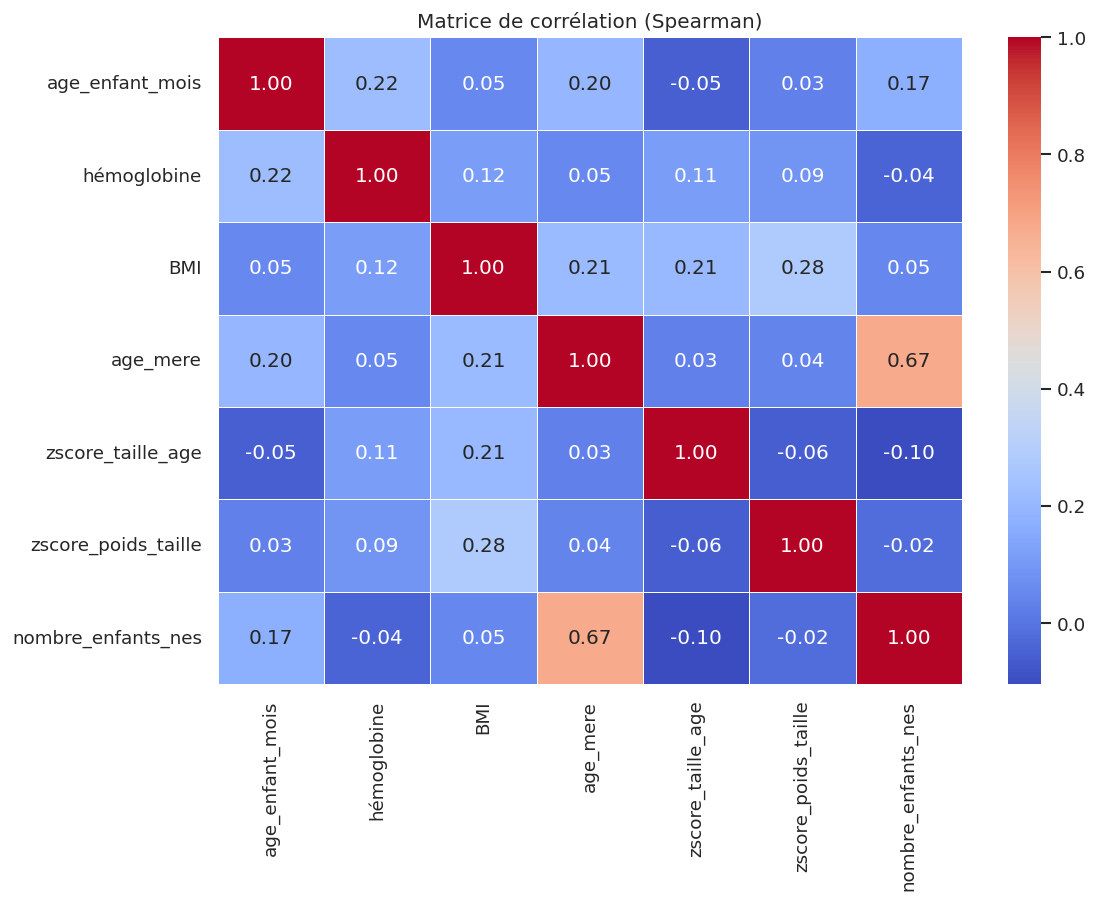

In [ ]:
# Corrélation de Spearman

# Elle sert à mesurer :

# la relation monotone entre DEUX variables quantitatives.

# H0 il n’existe pas de corrélation entre les deux variables. ρ = 0
# H1 il existe une corrélation. ρ ≠ 0

# ══════════════════════════════════════════════════════
#           ANALYSE DE CORRÉLATION — SPEARMAN
# ══════════════════════════════════════════════════════

from scipy.stats import spearmanr
import pandas as pd

# Variables quantitatives
vars_num = [
    'age_enfant_mois',
    'hémoglobine',
    'BMI',
    'age_mere',
    'zscore_taille_age',
    'zscore_poids_taille',
    'nombre_enfants_nes'
]

print(f"\n{'Variable 1':<30} {'Variable 2':<30} {'Rho':>8} {'p-value':>10} {'Sig':>6}")
print("-"*95)

# Boucle sur toutes les combinaisons
for i in range(len(vars_num)):
    
    for j in range(i+1, len(vars_num)):
        
        var1 = vars_num[i]
        var2 = vars_num[j]
        
        # suppression des NA
        temp = dfKR[[var1, var2]].dropna()
        
        # Corrélation de Spearman
        rho, p = spearmanr(temp[var1], temp[var2])
        
        # significativité
        sig = "✅" if p < 0.05 else "❌"
        
        print(f"{var1:<30} {var2:<30} {rho:>8.3f} {p:>10.4f} {sig:>6}")

import seaborn as sns
import matplotlib.pyplot as plt

# Variables quantitatives
vars_num = [
    'age_enfant_mois',
    'hémoglobine',
    'BMI',
    'age_mere',
    'zscore_taille_age',
    'zscore_poids_taille',
    'nombre_enfants_nes'
]

# Matrice de corrélation Spearman
corr = dfKR[vars_num].corr(method='spearman')

# Affichage tableau
print(corr)

# Heatmap
plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Matrice de corrélation (Spearman)")
plt.show()

In [ ]:
# ==============================================================
# MODÈLE DE RÉGRESSION ORDINALE MULTINIVEAU
# Bambi — Famille Cumulative (Logit cumulatif)
# Anémie chez les enfants < 5 ans — EDS Cameroun
# ==============================================================

from statsmodels.miscmodels.ordinal_model import OrderedModel
import statsmodels.api as sm
from scipy import stats


# ==============================================================
# ÉTAPE 1 : PRÉPARATION DES DONNÉES
# ==============================================================

vars_x = [
    'age_enfant_mois',
    'zscore_taille_age',
    'zscore_poids_taille',
    'diarrhee',
    'fievre',
    'anemie_mere',
    'milieu_residence',
    'indice_richesse',
    'niveau_instruction',
    'age_mere',
    'BMI'
]

# Dataset sans NaN
df_modelV = dfKR[['anemie', 'cluster', 'region'] + vars_x].dropna()

# Variable dépendante ordinale
df_modelV['anemie'] = pd.Categorical(
    df_modelV['anemie'].astype(int),
    categories=[0, 1, 2],
    ordered=True
)

# ==============================================================
# ÉTAPE 2 : ENCODAGE + CORRECTION DES TYPES  ← ICI
# ==============================================================

# Encodage des variables catégorielles
df_encoded = pd.get_dummies(
    df_modelV[vars_x],
    drop_first=True
)

# Forcer toutes les colonnes en numérique
df_encoded = df_encoded.apply(pd.to_numeric, errors='coerce')

# Vérifier s'il reste des colonnes object
cols_object = df_encoded.select_dtypes(include='object').columns.tolist()
if cols_object:
    print(f"⚠️ Colonnes encore en object : {cols_object}")
else:
    print("✅ Toutes les colonnes sont numériques")

# Supprimer les NaN résiduels et aligner les index
df_encoded = df_encoded.dropna()
df_modelV  = df_modelV.loc[df_encoded.index]

# print(f"✅ Données prêtes : {df_modelV.shape[0]} observations")
# print(f"✅ Nombre de clusters : {df_modelV['cluster'].nunique()}")
# print(f"✅ Nombre de régions  : {df_modelV['region'].nunique()}")

# ==============================================================
# ÉTAPE 3 : MODÈLE ORDINAL MULTIVARIÉ (effets fixes)
# ==============================================================

print("\n" + "="*60)
print("  MODÈLE 1 — ORDINAL MULTIVARIÉ (effets fixes)")
print("="*60)

model_ordinal = OrderedModel(
    df_modelV['anemie'],
    df_encoded.astype(float),  # forcer float explicitement
    distr='logit'
)

result_ordinal = model_ordinal.fit(
    method='bfgs',
    disp=True,
    maxiter=1000
)

print(result_ordinal.summary())


✅ Toutes les colonnes sont numériques

  MODÈLE 1 — ORDINAL MULTIVARIÉ (effets fixes)
Optimization terminated successfully.
         Current function value: 1.017257
         Iterations: 94
         Function evaluations: 97
         Gradient evaluations: 97
                             OrderedModel Results                             
Dep. Variable:                 anemie   Log-Likelihood:                -4055.8
Model:                   OrderedModel   AIC:                             8152.
Method:            Maximum Likelihood   BIC:                             8277.
Date:                Fri, 22 May 2026                                         
Time:                        13:40:40                                         
No. Observations:                3987                                         
Df Residuals:                    3967                                         
Df Model:                          18                                         
                           coef

In [ ]:
# ==============================================================
# ÉTAPE 3 : CORRECTION MULTINIVEAU
# Erreurs standard robustes clusterisées (niveau cluster)
# ==============================================================

print("\n" + "="*60)
print("  MODÈLE 2 — CORRECTION MULTINIVEAU")
print("  (Erreurs standard robustes clusterisées)")
print("="*60)

result_robust = model_ordinal.fit(
    method     = 'bfgs',
    disp       = False,
    cov_type   = 'cluster',
    cov_kwds   = {'groups': model_ordinal['cluster'].values}
)

print(result_robust.summary())


  MODÈLE 2 — CORRECTION MULTINIVEAU
  (Erreurs standard robustes clusterisées)


NameError: name 'model_ordinal' is not defined

In [ ]:
# ==============================================================
# ÉTAPE 4 : TABLEAU COMPARATIF
# ==============================================================

print("\n" + "="*60)
print("  COMPARAISON — Standard vs Robuste Clusterisé")
print("="*60)

coef      = result_ordinal.params
se_std    = result_ordinal.bse
se_robust = result_robust.bse
pval_std  = result_ordinal.pvalues
pval_rob  = result_robust.pvalues

tableau = pd.DataFrame({
    'Coeff'       : coef.round(4),
    'SE Standard' : se_std.round(4),
    'SE Robuste'  : se_robust.round(4),
    'p Standard'  : pval_std.round(4),
    'p Robuste'   : pval_rob.round(4),
    'Sig Robuste' : pval_rob.apply(
        lambda p: '***' if p<0.001 else '**' if p<0.01
                  else '*' if p<0.05 else '.'  if p<0.1
                  else 'NS'
    )
})

print(tableau.to_string())


  COMPARAISON — Standard vs Robuste Clusterisé
                       Coeff  SE Standard  SE Robuste  p Standard  p Robuste Sig Robuste
age_enfant_mois      -0.0246       0.0021      0.0021      0.0000     0.0000         ***
zscore_taille_age    -0.0833       0.0193      0.0197      0.0000     0.0000         ***
zscore_poids_taille  -0.0956       0.0240      0.0262      0.0001     0.0003         ***
diarrhee              0.0542       0.0924      0.0986      0.5575     0.5828          NS
fievre                0.4200       0.0809      0.0918      0.0000     0.0000         ***
age_mere             -0.0038       0.0050      0.0051      0.4447     0.4532          NS
BMI                  -0.0028       0.0071      0.0075      0.6960     0.7113          NS
anemie_mere_2         0.2868       0.0995      0.1106      0.0040     0.0095          **
anemie_mere_0        -0.5396       0.0757      0.0864      0.0000     0.0000         ***
anemie_mere_3         0.2261       0.4055      0.4305      0.5

In [ ]:
# ==============================================================
# ÉTAPE 5 : ODDS RATIOS
# ==============================================================

print("\n" + "="*60)
print("  ODDS RATIOS (exp(coeff))")
print("="*60)

or_df = pd.DataFrame({
    'Odds Ratio' : np.exp(coef).round(4),
    'IC 2.5%'   : np.exp(coef - 1.96 * se_robust).round(4),
    'IC 97.5%'  : np.exp(coef + 1.96 * se_robust).round(4),
    'p-value'   : pval_rob.round(4),
    'Sig'       : pval_rob.apply(
        lambda p: '***' if p<0.001 else '**' if p<0.01
                  else '*' if p<0.05 else 'NS'
    )
})

print(or_df.to_string())


  ODDS RATIOS (exp(coeff))
                      Odds Ratio  IC 2.5%  IC 97.5%  p-value  Sig
age_enfant_mois           0.9757   0.9716    0.9798   0.0000  ***
zscore_taille_age         0.9200   0.8852    0.9562   0.0000  ***
zscore_poids_taille       0.9089   0.8633    0.9569   0.0003  ***
diarrhee                  1.0557   0.8701    1.2809   0.5828   NS
fievre                    1.5219   1.2713    1.8220   0.0000  ***
age_mere                  0.9962   0.9864    1.0061   0.4532   NS
BMI                       0.9972   0.9827    1.0120   0.7113   NS
anemie_mere_2             1.3322   1.0726    1.6547   0.0095   **
anemie_mere_0             0.5830   0.4921    0.6906   0.0000  ***
anemie_mere_3             1.2537   0.5392    2.9149   0.5995   NS
milieu_residence_0        0.8698   0.7158    1.0568   0.1604   NS
indice_richesse_2         1.2559   1.0224    1.5427   0.0299    *
indice_richesse_1         1.1416   0.8957    1.4550   0.2846   NS
indice_richesse_4         0.8234   0.6683    1.0

In [ ]:
# ==============================================================
# ÉTAPE 6 : QUALITÉ DU MODÈLE
# ==============================================================

print("\n" + "="*60)
print("  QUALITÉ DU MODÈLE")
print("="*60)

print(f"  Log-Likelihood  : {result_robust.llf:.4f}")
print(f"  AIC             : {result_robust.aic:.4f}")
print(f"  BIC             : {result_robust.bic:.4f}")
print(f"  Pseudo R² McF   : "
      f"{1 - result_robust.llf / result_robust.llnull:.4f}")


  QUALITÉ DU MODÈLE
  Log-Likelihood  : -4055.8020
  AIC             : 8151.6040
  BIC             : 8277.4198
  Pseudo R² McF   : 0.0553


In [ ]:
# ==============================================================
# MACHINE LEARNING — PRÉDICTION DU STATUT ANÉMIQUE
# Random Forest + XGBoost + Régression Logistique Multinomiale
# EDS Cameroun 2018
# ==============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             accuracy_score, f1_score)


# ==============================================================
# ÉTAPE 1 — TRAIN / TEST SPLIT
# ==============================================================

X = df_encoded.copy()
y = df_modelV['anemie'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y
)

print("="*55)
print("  ÉTAPE 1 — DONNÉES")
print("="*55)
print(f" Train : {X_train.shape[0]} observations")
print(f" Test  : {X_test.shape[0]}  observations")
print(f"\nDistribution y_train :")
print(y_train.value_counts().sort_index()
      .rename({0:'Pas anémie', 1:'Légère', 2:'Modérée-Sév'})
      .to_string())
print(f"\nDistribution y_test  :")
print(y_test.value_counts().sort_index()
      .rename({0:'Pas anémie', 1:'Légère', 2:'Modérée-Sév'})
      .to_string())


  ÉTAPE 1 — DONNÉES
 Train : 3189 observations
 Test  : 798  observations

Distribution y_train :
anemie
Pas anémie     1356
Légère          814
Modérée-Sév    1019

Distribution y_test  :
anemie
Pas anémie     339
Légère         204
Modérée-Sév    255


In [ ]:
# ==============================================================
# ÉTAPE 2 — RANDOM FOREST
# ==============================================================

print("\n" + "="*55)
print("  ÉTAPE 2 — RANDOM FOREST")
print("="*55)

rf = RandomForestClassifier(
    n_estimators = 300,
    max_depth    = 10,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(f" Modèle entraîné sur {X_train.shape[0]} observations")
print(f"\nAccuracy   : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"F1 Macro   : {f1_score(y_test, y_pred_rf, average='macro'):.4f}")
print(f"F1 Weighted: {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"\nRapport détaillé :\n")
print(classification_report(
    y_test, y_pred_rf,
    target_names=['Pas anémie', 'Légère', 'Modérée-Sévère']
))


  ÉTAPE 2 — RANDOM FOREST
 Modèle entraîné sur 3189 observations

Accuracy   : 0.4937
F1 Macro   : 0.4513
F1 Weighted: 0.4783

Rapport détaillé :

                precision    recall  f1-score   support

    Pas anémie       0.56      0.62      0.59       339
        Légère       0.35      0.20      0.26       204
Modérée-Sévère       0.46      0.56      0.51       255

      accuracy                           0.49       798
     macro avg       0.46      0.46      0.45       798
  weighted avg       0.48      0.49      0.48       798



In [ ]:
# ==============================================================
# ÉTAPE 3 — RÉGRESSION LOGISTIQUE MULTINOMIALE
# ==============================================================

print("\n" + "="*55)
print("  ÉTAPE 3 — RÉGRESSION LOGISTIQUE MULTINOMIALE")
print("="*55)

lr = LogisticRegression(
    multi_class  = 'multinomial',
    solver       = 'lbfgs',
    max_iter     = 1000,
    class_weight = 'balanced',
    random_state = 42
)

lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print(f" Modèle entraîné sur {X_train.shape[0]} observations")
print(f"\nAccuracy   : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"F1 Macro   : {f1_score(y_test, y_pred_lr, average='macro'):.4f}")
print(f"F1 Weighted: {f1_score(y_test, y_pred_lr, average='weighted'):.4f}")
print(f"\nRapport détaillé :\n")
print(classification_report(
    y_test, y_pred_lr,
    target_names=['Pas anémie', 'Légère', 'Modérée-Sévère']
))



  ÉTAPE 3 — RÉGRESSION LOGISTIQUE MULTINOMIALE
 Modèle entraîné sur 3189 observations

Accuracy   : 0.4649
F1 Macro   : 0.4386
F1 Weighted: 0.4613

Rapport détaillé :

                precision    recall  f1-score   support

    Pas anémie       0.57      0.55      0.56       339
        Légère       0.30      0.25      0.28       204
Modérée-Sévère       0.45      0.53      0.48       255

      accuracy                           0.46       798
     macro avg       0.44      0.44      0.44       798
  weighted avg       0.46      0.46      0.46       798



In [ ]:
# ==============================================================
# ÉTAPE 4 — TABLEAU COMPARATIF
# ==============================================================

print("\n" + "="*55)
print("  ÉTAPE 4 — COMPARAISON DES MODÈLES")
print("="*55)

resultats = pd.DataFrame({
    'Modèle'      : ['Random Forest',
                     'Logistique Multinomiale'],
    'Accuracy'    : [accuracy_score(y_test, y_pred_rf),
                     accuracy_score(y_test, y_pred_lr)],
    'F1 Macro'    : [f1_score(y_test, y_pred_rf, average='macro'),
                     f1_score(y_test, y_pred_lr, average='macro')],
    'F1 Weighted' : [f1_score(y_test, y_pred_rf, average='weighted'),
                     f1_score(y_test, y_pred_lr, average='weighted')]
}).round(4)

print(resultats.to_string(index=False))

# Meilleur modèle
meilleur = resultats.loc[resultats['F1 Macro'].idxmax(), 'Modèle']
print(f"\n Meilleur modèle (F1 Macro) : {meilleur}")


  ÉTAPE 4 — COMPARAISON DES MODÈLES
                 Modèle  Accuracy  F1 Macro  F1 Weighted
          Random Forest    0.4937    0.4513       0.4783
Logistique Multinomiale    0.4649    0.4386       0.4613

 Meilleur modèle (F1 Macro) : Random Forest



  ÉTAPE 5 — MATRICES DE CONFUSION


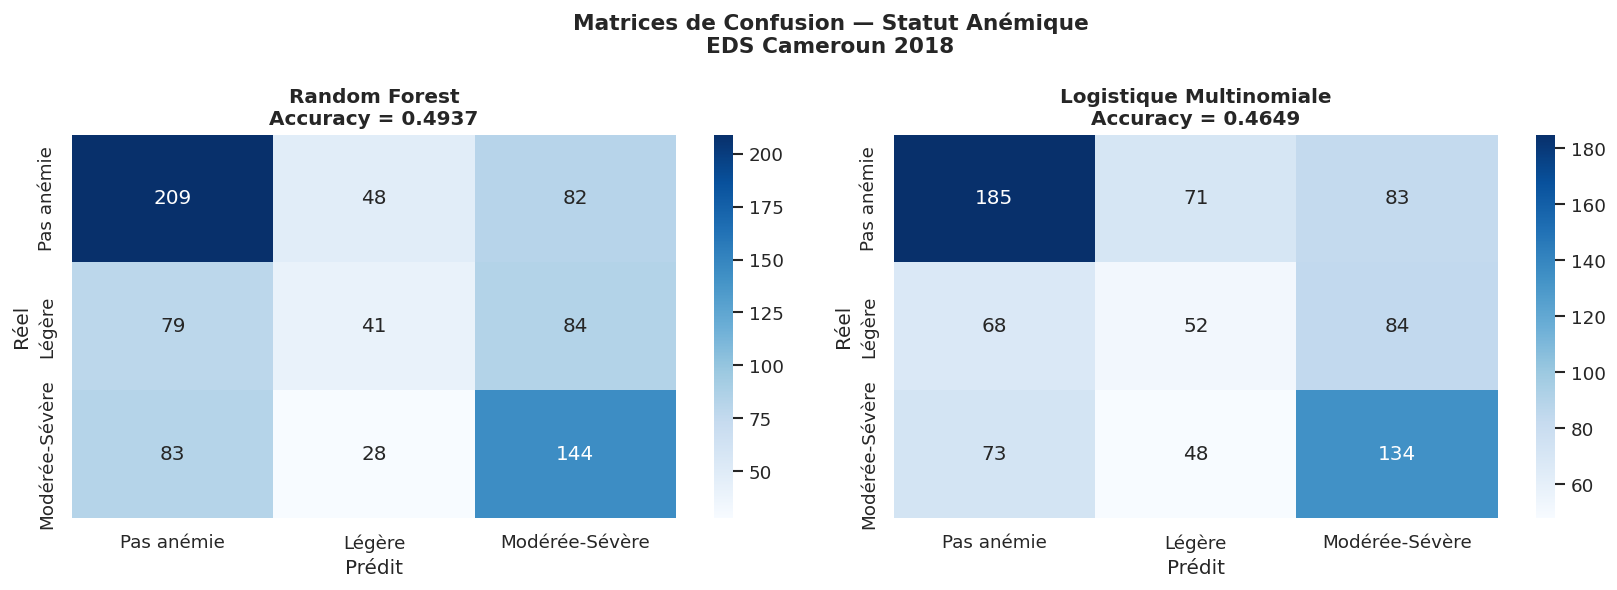

 Figure sauvegardée : matrices_confusion.png


In [ ]:
# ==============================================================
# ÉTAPE 5 — MATRICES DE CONFUSION
# ==============================================================

print("\n" + "="*55)
print("  ÉTAPE 5 — MATRICES DE CONFUSION")
print("="*55)

labels = ['Pas anémie', 'Légère', 'Modérée-Sévère']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (nom, y_pred) in zip(axes, [
    ('Random Forest',           y_pred_rf),
    ('Logistique Multinomiale', y_pred_lr)
]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels,
                yticklabels=labels, ax=ax)
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{nom}\nAccuracy = {acc:.4f}',
                 fontweight='bold')
    ax.set_ylabel('Réel')
    ax.set_xlabel('Prédit')

plt.suptitle(
    'Matrices de Confusion — Statut Anémique\nEDS Cameroun 2018',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figure sauvegardée : matrices_confusion.png")


  ÉTAPE 6 — IMPORTANCE DES VARIABLES

Top 10 variables les plus importantes :
age_enfant_mois         0.1648
BMI                     0.1576
zscore_taille_age       0.1522
zscore_poids_taille     0.1498
age_mere                0.1189
anemie_mere_0           0.0326
fievre                  0.0258
milieu_residence_0      0.0255
indice_richesse_2       0.0218
niveau_instruction_1    0.0214


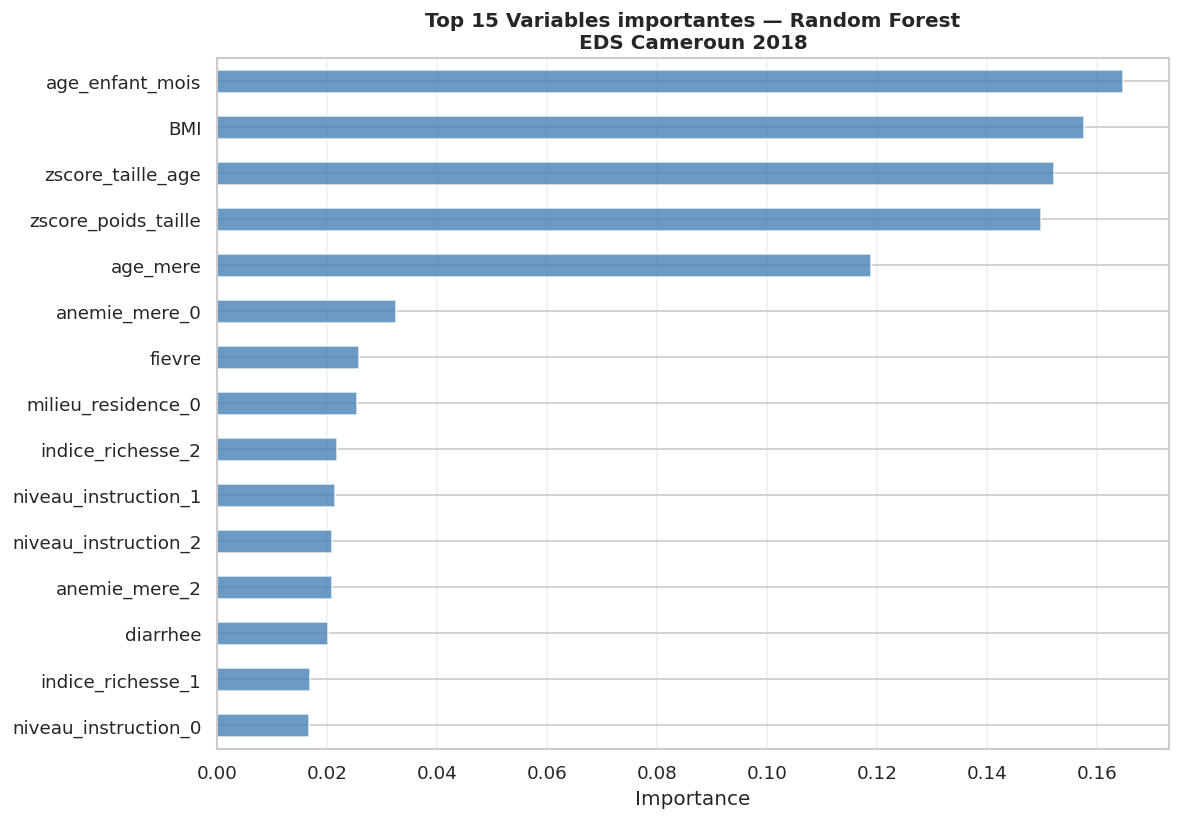

 Figure sauvegardée : importance_variables.png


In [ ]:
# ==============================================================
# ÉTAPE 6 — IMPORTANCE DES VARIABLES (Random Forest)
# ==============================================================

print("\n" + "="*55)
print("  ÉTAPE 6 — IMPORTANCE DES VARIABLES")
print("="*55)

importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nTop 10 variables les plus importantes :")
print(importances.head(10).round(4).to_string())

# Graphique
fig, ax = plt.subplots(figsize=(10, 7))
importances.sort_values(ascending=True).tail(15).plot(
    kind='barh', ax=ax, color='steelblue', alpha=0.8
)
ax.set_title(
    'Top 15 Variables importantes — Random Forest\nEDS Cameroun 2018',
    fontweight='bold'
)
ax.set_xlabel('Importance')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('importance_variables.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figure sauvegardée : importance_variables.png")

In [ ]:
# ==============================================================
# ==============================================================
# ÉTAPE 7 — SYNTHÈSE FINALE
# ==============================================================

print("\n" + "="*55)
print("  SYNTHÈSE FINALE")
print("="*55)
print(f"  Observations totales : {len(y)}")
print(f"  Train                : {len(y_train)} (80%)")
print(f"  Test                 : {len(y_test)}  (20%)")
print(f"\n  Random Forest")
print(f"    Accuracy   : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"    F1 Macro   : {f1_score(y_test, y_pred_rf, average='macro'):.4f}")
print(f"\n  Logistique Multinomiale")
print(f"    Accuracy   : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"    F1 Macro   : {f1_score(y_test, y_pred_lr, average='macro'):.4f}")
print(f"\n   Meilleur modèle : {meilleur}")


  SYNTHÈSE FINALE
  Observations totales : 3987
  Train                : 3189 (80%)
  Test                 : 798  (20%)

  Random Forest
    Accuracy   : 0.4937
    F1 Macro   : 0.4513

  Logistique Multinomiale
    Accuracy   : 0.4649
    F1 Macro   : 0.4386

   Meilleur modèle : Random Forest


In [ ]:
# Prédictions du modèle ordinal sur X_test
y_pred_ordinal = result_robust.predict(X_test)
y_pred_ordinal_class = np.argmax(y_pred_ordinal.values, axis=1)

# Comparaison
modeles_comp = {
    'Régression Ordinale' : y_pred_ordinal_class,
    'Random Forest'       : y_pred_rf
}

print(f"{'Modèle':<25} {'Accuracy':>10} {'F1 Macro':>10}")
print("-" * 47)
for nom, y_pred in modeles_comp.items():
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')
    print(f"{nom:<25} {acc:>10.4f} {f1:>10.4f}")

# Meilleur modèle
meilleur = max(modeles_comp,
               key=lambda m: f1_score(y_test,
               modeles_comp[m], average='macro'))
print(f"\n Meilleur modèle : {meilleur}")

Modèle                      Accuracy   F1 Macro
-----------------------------------------------
Régression Ordinale           0.4912     0.3662
Random Forest                 0.4937     0.4513

 Meilleur modèle : Random Forest


In [ ]:
# Exporter les modèles depuis ton notebook
import joblib
import json
import numpy as np

# ── Sauvegarder le Random Forest ──────────────────────
joblib.dump(rf, 'rf.pkl')

# ── Sauvegarder le modèle ordinal ─────────────────────
joblib.dump(result_robust, 'result_robust.pkl')

# ── Sauvegarder les colonnes exactes de X ─────────────
colonnes = X.columns.tolist()
with open('colonnes_model.json', 'w') as f:
    json.dump(colonnes, f)

print(" Modèles sauvegardés :")
print(f"   - random_forest_anemie.pkl")
print(f"   - ordinal_anemie.pkl")
print(f"   - colonnes_model.json")
print(f"\nColonnes ({len(colonnes)}) :")
for c in colonnes:
    print(f"   {c}")

NameError: name 'rf' is not defined